# Projeto Fundamentos de Aprendizagem Automática

**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

## Problema
**Prever a nota final** com base em todas as variáveis comportamentais, exceto 


* student_id
* productivity_score  
* burnout_level 
* focus_index
    

## Variáveis-Alvo (Targets)

### Cenário de Classificação (y)

Transformar a variável _Exam Score_ em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:

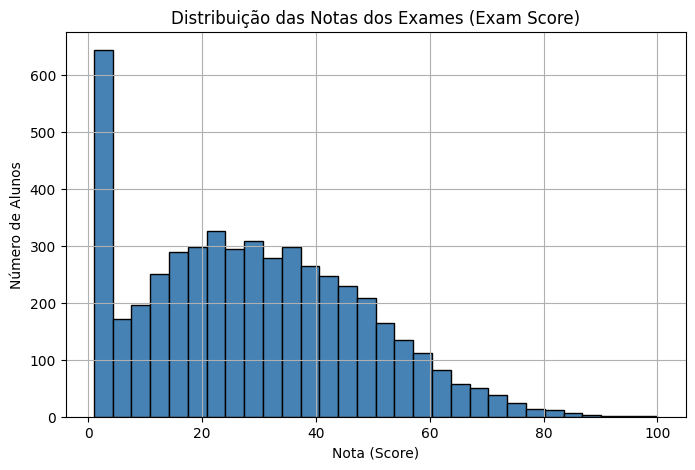

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Ler os dados
df = pd.read_csv('student_records_missing.csv')

# print(df["exam_score"].min(), df["exam_score"].max())



scaler = MinMaxScaler(feature_range=(1, 100))
df["exam_score"] = scaler.fit_transform(df[["exam_score"]])

df['exam_score'].hist(bins=30, color='steelblue', edgecolor='black', figsize=(8, 5))
plt.title('Distribuição das Notas dos Exames (Exam Score)')
plt.xlabel('Nota (Score)')
plt.ylabel('Número de Alunos')
plt.show()


**Classificação multiclass (Nota entre 0 até 65):**

|**Categoria**|**Intervalo (Exam Score)**|
|---|---|
|**Insuficiente**|0 a 39|
|**Suficiente**|40 a 100|


Com base nos dados que estão muito desbalanceado, decidimos fazer uma classificação binária, e após utilizarmos scaling para transformar o intervalo de [1, 65] em [1, 100], reparámos que a maior parte de os alunos teria chumbado se a divisão fosse efetuada exatamente a meio, para mitigar este acontecimento, consideramos Suficiente todas as notas >40.


## Stakeholders

- **Os próprios estudantes** :Beneficiariam ao compreender de forma clara como os seus hábitos de vida (como as horas de sono, tempo de ecrã e o balanço entre estudo e lazer) impactam diretamente o seu desempenho académico. Ter acesso a esta previsão permite-lhes ajustar comportamentos de forma proativa e atempada, evitando o insucesso escolar (chumbo) ou níveis extremos de exaustão (burnout).
    
- **A instituição de ensino / Escola** :Pode utilizar este modelo preditivo para identificar antecipadamente uma percentagem de alunos em risco de reprovação. Isto permite à gestão escolar uma melhor alocação de recursos pedagógicos, como a promoção de turmas de apoio extra ou a reavaliação da carga de trabalhos exigida.
    
- **Conselheiros / Tutores** :Passam a ter acesso a uma ferramenta de apoio à decisão baseada em dados reais para oferecer um acompanhamento muito mais personalizado. Em vez de conselhos genéricos, o tutor pode focar-se nas variáveis específicas que o modelo identificou como problemáticas para um determinado aluno (por exemplo, excesso de horas em videojogos ou falta de qualidade de sono).
    
- **Serviços de Apoio ao Estudante(Apoio Psicológico)** :Podem atuar de forma preventiva junto de alunos cujo perfil cruze um baixo rendimento académico com indicadores de má saúde mental (como altos níveis de ingestão de cafeína e privação de sono). O modelo serve como um sistema de alerta para oferecer suporte psicológico antes que o aluno atinja um ponto de rutura.


### 1. Ler ficheiro obter feature Variables e Target Variables e tratar dados missing

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder


# 1. ler ficherio de student_records com missing values
df_student_records = pd.read_csv('student_records_missing.csv')
df_colunas = df_student_records.columns


# imprimir percentagem missing values por coluna
missing_percent = df_student_records.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])




df_y = df_student_records["exam_score"].copy()  # Variável y com a coluna "exam_score"

# 2. Normalizar os valores de "exam_score" para a faixa de 1 a 100 usando MinMaxScaler
scaler = MinMaxScaler(feature_range=(1, 100))
df_y_scaled_array = scaler.fit_transform(df_y.to_frame())



# 3. Converter o array 2D de volta para uma Pandas Series (1D) O .flatten() transforma algo como [[10], [50]] em [10, 50]
df_y_series = pd.Series(df_y_scaled_array.flatten())

# 4. Categorizar os valores de "exam_score" em "Insuficiente" e "Suficiente" com base no critério de corte de 40
def categorizar_exame_score(score):
    if score < 40:
        return 'Insuficiente'  
      
    else:
        return 'Suficiente'  

df_y_categorico = df_y_series.apply(categorizar_exame_score)

print(df_y_categorico.value_counts())

# 5. OrdinalEncoder (categories=categories) para transformar as categorias em números ordinais
categories = [["Insuficiente", "Suficiente",]]
oe = OrdinalEncoder(categories=categories)
df_y_categorico_ordinais = oe.fit_transform(df_y_categorico.to_frame())

# print(df_y_categorico_ordinais)


# 6. Definir Variável X
df_student_records.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
X = df_student_records.copy()  # Variável X com as colunas restantes

# print(X.head())





# 7. one split para separar os dados em treino e teste
X_learning, X_test, y_learning, y_test = train_test_split(
    X, df_y_categorico_ordinais, test_size=0.2, random_state=42, stratify=df_y_categorico_ordinais
)





# 8. Separar colunas numéricas e categóricas em X_learning para preencher os valores vazios
num_cols = X_learning.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_learning.select_dtypes(include=['object', 'string']).columns.tolist()



# 9. Calcular a mediana para as colunas numéricas e a moda para as colunas categóricas em X_learning
medians = X_learning[num_cols].median()
modes = X_learning[cat_cols].mode().iloc[0]

# print("\n Medianas para colunas numéricas:")
# print(medians)

# print("\n Modas para colunas categóricas:")
# print(modes)



# 10. Preencher os valores vazios em X_learning com as medianas e modas calculadas
X_learning[num_cols] = X_learning[num_cols].fillna(medians)
X_learning[cat_cols] = X_learning[cat_cols].fillna(modes)

# 11. Preencher os valores vazios em X_test com as mesmas medianas e modas calculadas a partir de X_learning
X_test[num_cols] = X_test[num_cols].fillna(medians)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)







print("\n Total atual de valores vazios :", X_learning.isnull().sum().sum() + X_test.isnull().sum().sum())
# print(X_learning.head())
# print(X_test.head())


# 12. Utilizando(One-Hot Encoding) para transformar as colunas categóricas em variáveis dummy
X_learning = pd.get_dummies(X_learning, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
# print(X_learning.head())







--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64
Insuficiente    3562
Suficiente      1438
Name: count, dtype: int64

 Total atual de valores vazios : 0


### Árvore de Decisão
#### 1. Utilizando GridSearchCV e Crosvalidation encontrar best parametro

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Treino e Avaliação de Modelos Base
param_grid = {
"criterion": ["gini", "entropy"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
estimator=tree.DecisionTreeClassifier(random_state=7),#Semente aleatória fixa para garantir reprodutibilidade
param_grid=param_grid,#Grelha de hiperparâmetros definida acima.
scoring="f1",#Utilizar a acurácia como métrica de avaliação do modelo
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=7),#Validação cruzada estratificada de 5 folds, mantendo a proporção das classes em cada fold e embaralhando os dados antes da divisão.
n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar apenas no conjunto de aprendizagem

print("Best parameters:", grid.best_params_)
print("Best mean CV F1:", round(grid.best_score_, 3))


#utilizando bestest parameters para treinar o modelo final
final_model = grid.best_estimator_ 
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision (macro)": precision_score(y_test, y_test_pred, average='macro'),
    "Precision (weighted)": precision_score(y_test, y_test_pred, average='weighted'),
    "Recall (macro)": recall_score(y_test, y_test_pred, average='macro'),
    "Recall (weighted)": recall_score(y_test, y_test_pred, average='weighted'),
    "F1": f1_score(y_test, y_test_pred),
})

final_metrics.round(3)






Best parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV F1: 0.654


Accuracy                0.803
Precision (macro)       0.767
Precision (weighted)    0.795
Recall (macro)          0.728
Recall (weighted)       0.803
F1                      0.617
dtype: float64

#### 2. Confusin matriz

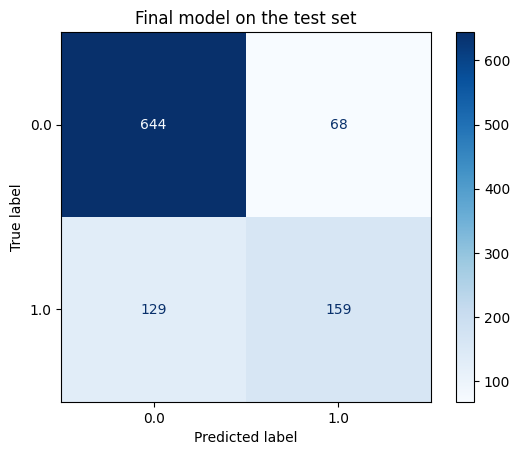

In [25]:
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap="Blues")
plt.title("Final model on the test set")
plt.show()

### 3 decision tree grafico

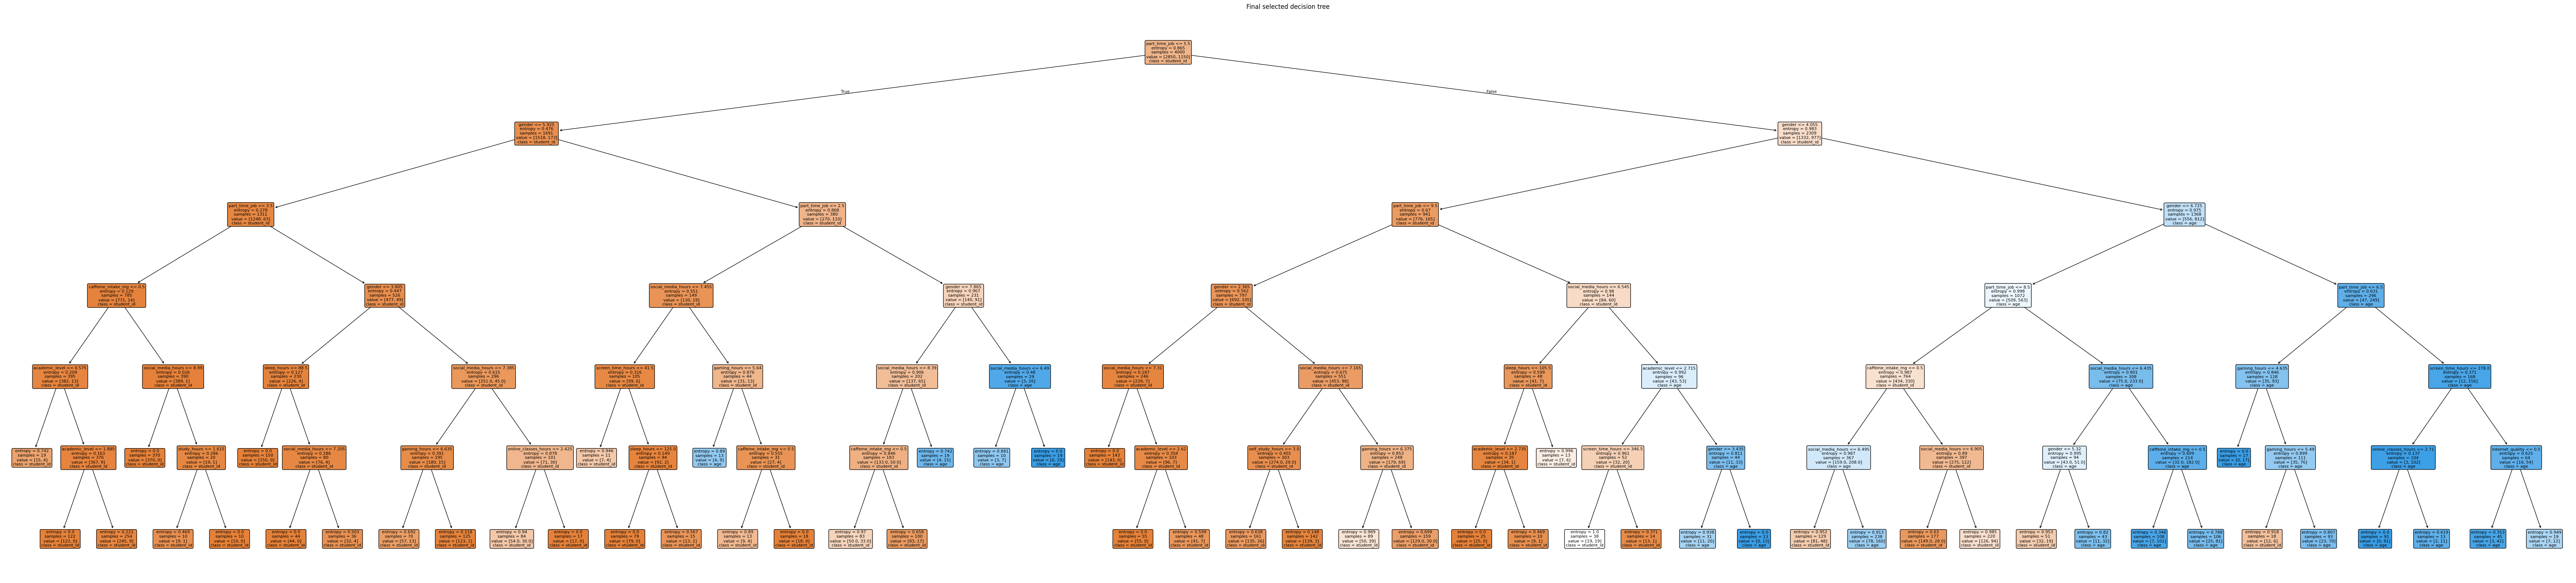

In [26]:
from sklearn.tree import plot_tree


plt.figure(figsize=(90, 20))
plot_tree(
final_model,
feature_names=X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,

)

plt.title("Final selected decision tree")
plt.show()

### KNN

In [27]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 


# 1. Criar um StandardScaler (apenas para as colunas numéricas)
scaler = StandardScaler()
X_learning_scaled = X_learning.copy()
X_test_scaled = X_test.copy()


X_learning_scaled[num_cols] = scaler.fit_transform(X_learning[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# print("\n=== KNN 专属数据 (经过标准化处理) ===")
# print(X_learning_scaled.head())



# 2. Colocar o KNN dentro do GridSearchCV para encontrar os melhores hiperparâmetros (n_neighbors, weights, p)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # KNN 最重要的参数就是找几个邻居
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

# 3. fit knn usando os dados de aprendizagem que foram preenchidos e padronizados
grid_knn.fit(X_learning_scaled, y_learning)

print("KNN Cross-Validation Best Parameters:", grid_knn.best_params_)
print("KNN Highest Average Cross-Validation F1:", round(grid_knn.best_score_, 3))


# 4. Testar o melhor modelo KNN encontrado no conjunto de teste (Test Set) e avaliar usando classification_report
best_knn_model = grid_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_scaled)

print("\n=== KNN (Test Set) Assessment ===")
print("KNN Test Set F1 Score:", round(f1_score(y_test, y_pred_knn), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_knn))




KNN Cross-Validation Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
KNN Highest Average Cross-Validation F1: 0.575

=== KNN (Test Set) Assessment ===
KNN Test Set F1 Score: 0.531

Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.94      0.86       712
         1.0       0.74      0.41      0.53       288

    accuracy                           0.79      1000
   macro avg       0.77      0.68      0.70      1000
weighted avg       0.78      0.79      0.77      1000



### KNN usando PCA

In [30]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings

# Ignorar os avisos (warnings) para manter o output limpo
warnings.filterwarnings('ignore')

# 1. Obter o número de características (features) originais para definir o limite do loop do PCA
N_componetes = len(X_learning_scaled.columns)
print("Número de componentes originais:", N_componetes)

resultado = []

# 2. Testar diferentes dimensões do PCA (de 1 até o número total de características originais)
for n in range(1, N_componetes + 1):
    # print(f"A treinar PCA com {n} componente(s)...")
    
    # 3. Aplicar redução de dimensionalidade com PCA
    pca = PCA(n_components=n)
    X_learning_pca_scaled = pca.fit_transform(X_learning_scaled) 
    X_test_pca_scaled = pca.transform(X_test_scaled)

    param_grid_knn = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
    
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 4. Procurar os melhores hiperparâmetros do KNN para a dimensão atual usando GridSearchCV
    grid_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        scoring='f1', # Para classificação binária, usamos 'f1' diretamente
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_knn.fit(X_learning_pca_scaled, y_learning)
    best_knn_model = grid_knn.best_estimator_

    # 5. Fazer previsões no conjunto de teste (Test Set)
    y_pred_knn = best_knn_model.predict(X_test_pca_scaled)
    # Extrair a probabilidade de pertencer à classe positiva (índice 1) para o cálculo do ROC AUC
    y_prob_knn = best_knn_model.predict_proba(X_test_pca_scaled)[:, 1] 

    # 6. Guardar os resultados das métricas de avaliação
    pca_results = {
        "n_components": n,                                     # Registar o número de componentes
        "best_k": best_knn_model.n_neighbors,                  # Registar o melhor valor de vizinhos (k)
        "best_weights": best_knn_model.weights,                # Registar a melhor métrica de peso
        "accuracy": accuracy_score(y_test, y_pred_knn),
        "precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "f1": f1_score(y_test, y_pred_knn),
        "roc_auc": roc_auc_score(y_test, y_prob_knn)           # Área sob a curva ROC
    }
    
    resultado.append(pca_results)

# 7. Converter a lista de resultados num Pandas DataFrame
df_resultados = pd.DataFrame(resultado)

# 8. Ordenar os resultados pela pontuação F1 (ordem decrescente)
df_resultados_sorted = df_resultados.sort_values(by='f1', ascending=False).reset_index(drop=True)

print("\n=== Desempenho no Conjunto de Teste: PCA + KNN por Dimensão ===")
# Usar display() no Jupyter Notebook para visualizar uma tabela formatada (ou print() num script normal)
display(df_resultados_sorted)

Número de componentes originais: 22

=== Desempenho no Conjunto de Teste: PCA + KNN por Dimensão ===


,n_components,best_k,best_weights,accuracy,precision,recall,f1,roc_auc
0,9,5,distance,0.790,0.677273,0.517361,0.586614,0.805497
1,10,9,distance,0.800,0.736559,0.475694,0.578059,0.834613
2,12,9,uniform,0.802,0.758621,0.458333,0.571429,0.841602
3,11,11,distance,0.797,0.734807,0.461806,0.567164,0.851609
4,18,9,uniform,0.795,0.731844,0.454861,0.561028,0.828893
5,16,9,uniform,0.784,0.697802,0.440972,0.540426,0.826967
6,13,9,uniform,0.786,0.712644,0.430556,0.536797,0.843033
7,17,7,uniform,0.786,0.712644,0.430556,0.536797,0.802096
8,21,11,uniform,0.790,0.743750,0.413194,0.531250,0.833316
9,20,11,uniform,0.790,0.743750,0.413194,0.531250,0.833316


### Sequential feature selection para KNN

### Gaussian Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report




gnb = GaussianNB()




cv_strategy_gnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# 跑 5 次模拟考，由于不需要调参，直接用 cross_val_score
cv_scores_gnb = cross_val_score(gnb, X_learning, y_learning, cv=cv_strategy_gnb, scoring='accuracy')

print("Valor médio de cross-validation:", round(cv_scores_gnb.mean(), 3))


gnb.fit(X_learning, y_learning)


y_pred_gnb = gnb.predict(X_test)


print("Gaussian NB Test Set F1 Score:", round(f1_score(y_test, y_pred_gnb), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_gnb, target_names=oe.categories_[0]))


Valor médio de cross-validation: 0.844
Gaussian NB Test Set F1 Score: 0.662

Detailed Classification Report:
               precision    recall  f1-score   support

Insuficiente       0.84      0.95      0.89       712
  Suficiente       0.83      0.55      0.66       288

    accuracy                           0.84      1000
   macro avg       0.83      0.75      0.78      1000
weighted avg       0.84      0.84      0.83      1000



### Escolher melhor modelo